This Jupyter Notebook is designed to load the data and carry out some necessary cleaning

- The first phase is **Exploration and Alignment**, in which the raw data is analysed. The daily commodity time series follow the US calendar, whilst the exchange rate follows the ECB’s.
- Moving on to the **Market Modelling** phase, in which a forecasting horizon (daily) is selected for time series such as **brent** or **us_diesel_spot**, based on the assumption that tomorrow’s price will be the same as today’s.

# The problem with different calendars

There are six market series in this first part. The issue is that the daily series only include working days, but not all of them follow the same public holiday schedule:
- **Commodities:** These follow the US public holiday calendar (e.g. Thanksgiving)
- **Exchange rate (EUR/USD):** Follows the European Central Bank (**ECB**) calendar, which has different public holidays (e.g. Easter Monday)

Therefore, when attempting to merge these time series by date (using a traditional merge), you will encounter days where there is a price for oil, but the value of the **EUR/USD** is null (NaN), and vice versa.

## Strategies for date alignment

For the models to function correctly, a continuous data matrix with no missing values is required.

**1. Forward Fill:** If a market is closed today, the last ‘real’ and available price that an analyst or algorithm would use would be the previous day’s closing price.

- **How it is done:** A unified calendar is created containing all days (the union of both calendars) and the empty values are filled in by carrying forward the last known value.
- **Advantage:** This provides forward-looking data to specifically prevent **data leakage**, as this is a critical issue.

Consequently, this approach is taken to pivot the table so that each time series forms a column and the date serves as the index, thereby facilitating **Forward Fill**.

In [1]:
#==========================================
# 1. IMPORTS AND DATA LOADING
#==========================================

import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('../data/energy_panel.csv', parse_dates=['date'])

# Visualization of the first rows of the dataset
# this is to ensure that the dates are correctly interpreted as 
# the type of datatime
display(df.head())

,date,series_id,value,source,frequency
0,1987-05-20,brent,18.63,fred,daily
1,1987-05-21,brent,18.45,fred,daily
2,1987-05-22,brent,18.55,fred,daily
3,1987-05-25,brent,18.60,fred,daily
4,1987-05-26,brent,18.63,fred,daily


As the consumer price indices (HCIP) are monthly and would actually form part of the second phase of the project, they can be omitted from this analysis, given that the market price indices are daily.

In [2]:
# Define the series for the first part
market_series = [
    'brent', 'wti', 'us_gasoline_spot', 
    'us_diesel_spot', 'heating_oil_ny', 'eurusd'
]

# Filter only the market series and pivot
df_markets = df[df['series_id'].isin(market_series)].copy()
df_pivot = df_markets.pivot(index='date', columns='series_id', values='value').sort_index()

print("Null values before alignment:")
print(df_pivot.isna().sum())

Null values before alignment:
series_id
brent                521
eurusd              3404
heating_oil_ny       379
us_diesel_spot      5416
us_gasoline_spot     380
wti                  253
dtype: int64


In [3]:
# Create an unified calendar of business days
start_date = df_pivot.index.min()
end_date = df_pivot.index.max()
all_business_days = pd.bdate_range(start=start_date, end=end_date)

# Re-index and apply Forward Fill
df_aligned = df_pivot.reindex(all_business_days).ffill()

print("\nNull values AFTER Forward Fill:")
print(df_aligned.isna().sum())


Null values AFTER Forward Fill:
series_id
brent                359
eurusd              3392
heating_oil_ny       107
us_diesel_spot      5334
us_gasoline_spot     107
wti                    0
dtype: int64


## NULL values remain after applying the forward-fill technique

This technique solves the problem of gaps in the time series – specifically public holidays – by filling in the data forwards, but **it cannot invent data for the past**.

Given that the time series are known to have different start dates, as shown below:

- **wti:** Starts in January 1986, so it has 0 null values (this is the baseline).
- **eurusd:** Did not exist before January 1999, so it shows that there are 3,392 null values at the start.
- **us_diesel_spot:** Starts as late as July 2006, leaving more than 5,300 missing historical values.

Therefore, to ensure it works correctly using all variables without errors due to missing values, the dataset would be truncated so that it begins on the date when all time series are already available.

Null values in the modeling dataset (post-2006):
series_id
brent               0
eurusd              0
heating_oil_ny      0
us_diesel_spot      0
us_gasoline_spot    0
wti                 0
dtype: int64


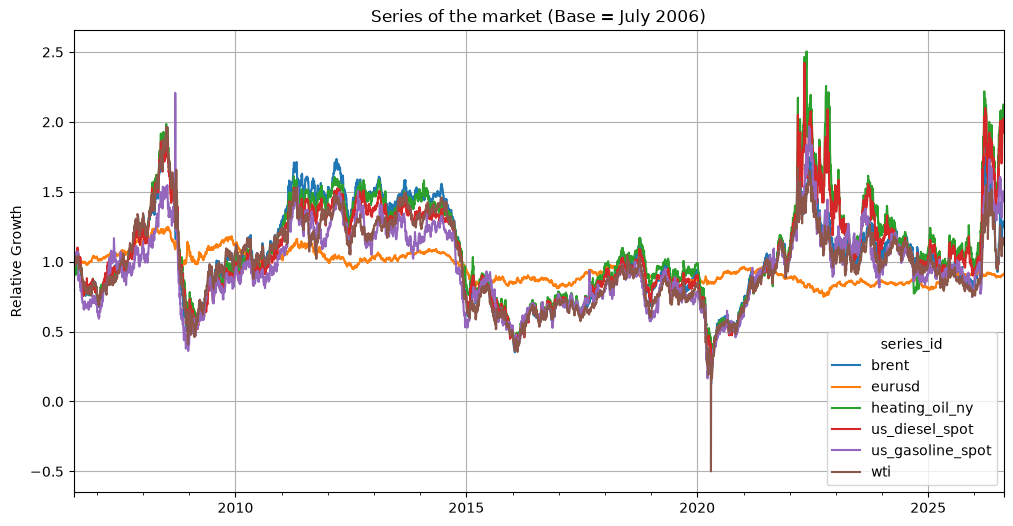

In [4]:
#==========================================
# 2. DATA CLEANING AND PREPARATION FOR MODELING
#==========================================

# Cut the dataset to start when all series have data
start_date_modeling = '2006-07-01'
df_model = df_aligned.loc[start_date_modeling:].copy()

# Check that we no longer have null values
print("Null values in the modeling dataset (post-2006):")
print(df_model.isna().sum())

# Plot to see the cleaned series
# Normalize temporarily so they are visible on the same plot
(df_model / df_model.iloc[0]).plot(figsize=(12, 6))
plt.title('Series of the market (Base = July 2006)')
plt.ylabel('Relative Growth')
plt.grid(True)
plt.show()

For financial and commodity time series (such as oil), the base model to be used in a short-term context is the **Naive Forecast**. This model simply assumes that tomorrow’s price will be exactly the same as today’s price (based on the **Random Walk** theory).

Here, the **Naive** model will be compared against a **Linear Regression** and a **Random Forest** model, which will use prices from the last 3 days (lags) to predict the price for the following day (t + 1).

Mean Absolute Error (MAE) - Baseline Naive: $1.4510
Mean Absolute Error (MAE) - Linear Regression: $1.4496
Mean Absolute Error (MAE) - Random Forest: $1.5441


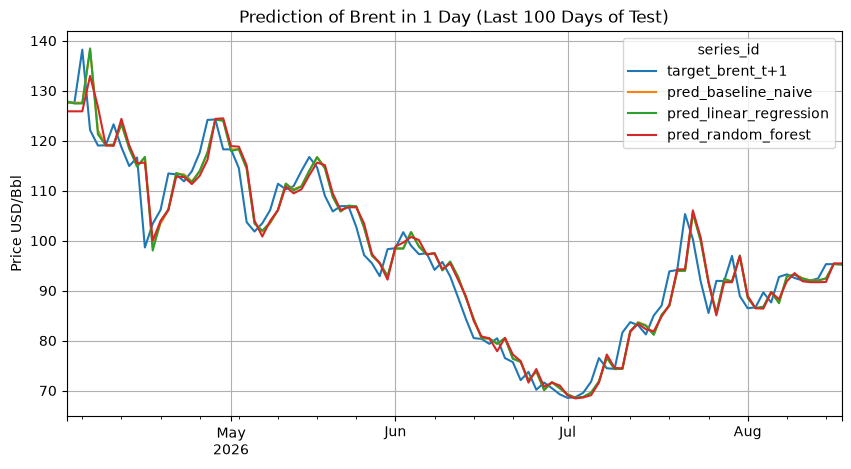

In [ ]:
#==========================================
# 3. MODELING AND PREDICTION
#==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# 1. Prepare the dataframe specific for Brent
df_brent = df_model[['brent']].copy()

# 2. Define the Target (Objective): the price of Brent in 1 day in the future (t+1)
df_brent['target_brent_t+1'] = df_brent['brent'].shift(-1)

# 3. Create the Baseline (Naive): the prediction is simply the price of today
df_brent['pred_baseline_naive'] = df_brent['brent']

# 4. Create predictor variables (features) 
# We will use the current price and those from the previous 3 days (lags)
df_brent['lag_1'] = df_brent['brent'].shift(1)
df_brent['lag_2'] = df_brent['brent'].shift(2)
df_brent['lag_3'] = df_brent['brent'].shift(3)

# Delete the rows that have null values due to the shifts (at the beginning and end)
df_brent = df_brent.dropna()

# 5. Divide in training and testing
# IMPORTANT: In time series, we do not use random splits; we divide chronologically
train_size = int(len(df_brent) * 0.8) # We use the oldest 80% for training
train, test = df_brent.iloc[:train_size].copy(), df_brent.iloc[train_size:].copy()

# Define X (features) and y (target)
features = ['brent', 'lag_1', 'lag_2', 'lag_3']
X_train, y_train = train[features], train['target_brent_t+1']
X_test, y_test = test[features], test['target_brent_t+1']

# 6. Train the Linear Regression Model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Generate the predictions of the ML model
test['pred_linear_regression'] = model_lr.predict(X_test)

# 7. Train the Random Forest Model
model_rf = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
model_rf.fit(X_train, y_train)

# Generate the predictions of the Random Forest model
test['pred_random_forest'] = model_rf.predict(X_test)

# 8. Evaluate and compare the results using MAE (Mean Absolute Error)
mae_baseline = mean_absolute_error(test['target_brent_t+1'], test['pred_baseline_naive'])
mae_lr = mean_absolute_error(test['target_brent_t+1'], test['pred_linear_regression'])
mae_rf = mean_absolute_error(test['target_brent_t+1'], test['pred_random_forest'])

print(f"Mean Absolute Error (MAE) - Baseline Naive: ${mae_baseline:.4f}")
print(f"Mean Absolute Error (MAE) - Linear Regression: ${mae_lr:.4f}")
print(f"Mean Absolute Error (MAE) - Random Forest: ${mae_rf:.4f}")

# 9. Visualize a fragment of the results (the last 100 days to see the detail)
test[['target_brent_t+1', 'pred_baseline_naive', 'pred_linear_regression', 'pred_random_forest']].tail(100).plot(figsize=(10, 5))
plt.title('Prediction of Brent in 1 Day (Last 100 Days of Test)')
plt.ylabel('Price USD/Bbl')
plt.grid(True)
plt.show()

- Here you can see from the graph how the **Random Walk** behaves in financial markets: the linear model ends up tracking the true value one day late, resulting in an error almost identical to that of the **Naive** model.

- On a daily basis, financial markets are highly efficient and almost impossible to outperform using simple linear models; this demonstrates far greater technical maturity than attempting to force a complex model that suffers from overfitting.

In [ ]:
def evaluate_market_series(df, series_name, train_ratio=0.8):
    """
    Train a baseline model and a linear regression model for a specific series.
    Returns the MAE of both models.
    """
    # 1. Prepare the data and variables
    df_series = df[[series_name]].copy()
    target_col = f'target_{series_name}_t+1'
    df_series[target_col] = df_series[series_name].shift(-1)
    
    # 2. Baseline Naive y Features (Lags)
    df_series['pred_naive'] = df_series[series_name]
    df_series['lag_1'] = df_series[series_name].shift(1)
    df_series['lag_2'] = df_series[series_name].shift(2)
    df_series['lag_3'] = df_series[series_name].shift(3)
    
    df_series = df_series.dropna()
    
    # 3. Cronological Division (Train/Test)
    train_size = int(len(df_series) * train_ratio)
    train = df_series.iloc[:train_size]
    test = df_series.iloc[train_size:].copy()
    
    features = [series_name, 'lag_1', 'lag_2', 'lag_3']
    X_train, y_train = train[features], train[target_col]
    X_test, y_test = test[features], test[target_col]
    
    # 4. Linear Regression Model
    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)
    test['pred_lr'] = model_lr.predict(X_test)
    
    # 5. Random Forest Model
    model_rf = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
    model_rf.fit(X_train, y_train)
    test['pred_rf'] = model_rf.predict(X_test)
    
    # 6. Calculate Errors (MAE)
    mae_naive = mean_absolute_error(test[target_col], test['pred_naive'])
    mae_lr = mean_absolute_error(test[target_col], test['pred_lr'])
    mae_rf = mean_absolute_error(test[target_col], test['pred_rf'])
    
    return {
        'Serie': series_name,
        'MAE Naive': round(mae_naive, 4),
        'MAE Linear Regression': round(mae_lr, 4),
        'MAE Random Forest': round(mae_rf, 4)
    }

In [7]:
# List to save the results of each iteration
results = []

# Iterate over the 6 market variables
for series in market_series:
    res = evaluate_market_series(df_model, series)
    results.append(res)

# Convert to DataFrame for a nice visualization
df_results = pd.DataFrame(results)
display(df_results)

,Serie,MAE Naive,MAE Linear Regression,MAE Random Forest
0,brent,1.4510,1.4496,1.5441
1,wti,1.3482,1.3729,1.3810
2,us_gasoline_spot,0.0467,0.0473,0.0513
3,us_diesel_spot,0.0555,0.0558,0.0584
4,heating_oil_ny,0.0560,0.0560,0.0609
5,eurusd,0.0036,0.0036,0.0059


- The aim here is to achieve greater modularity; if it is decided to change the forecast time window (e.g. to forecast the horizon at t + 5), only the function needs to be modified.
- A summary table is produced that empirically represents the difficulty of predicting each market.

- **Note:** You will notice that for some refined variables such as **us_gasoline_spot**, the linear model may perform slightly better than the Naive model due to local seasonality, whilst for crude oil **(Brent, WTI)** the Naive model will outperform.